In [53]:
#Churn Modeling Project
#Churn → When a customer stops using the company's service or leaves the company.
#Classification model based on availabel data whether the new customer coming to bank will leave( 0 ) or stay( 1 ) in the bank.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data=pd.read_csv('Churn_Modelling.csv')
data #View the given Data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [42]:
#Dropping the unnecessary columns that are non needed in our model

data.drop(['RowNumber','Surname','CustomerId'],axis=1,inplace=True) #inplace=True will update this in the dataframe
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [57]:
#Check whether data have present any null values in any column if there remove them 

data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

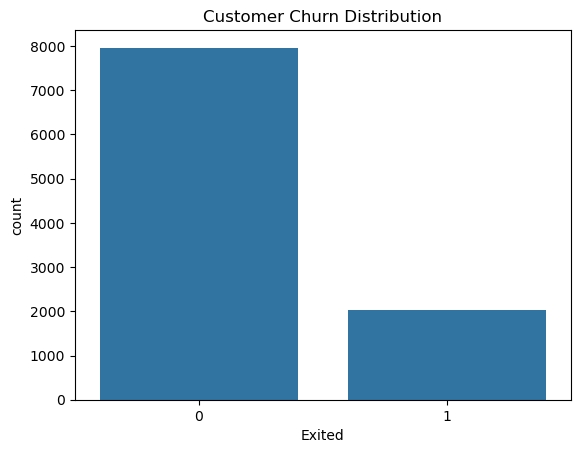

In [58]:
#Current Data Visualization
#Check how many customer churn in comparison to others that stay

import seaborn as sns
sns.countplot(x='Exited', data=data)
plt.title("Customer Churn Distribution")
plt.show()

<Axes: xlabel='Gender', ylabel='count'>

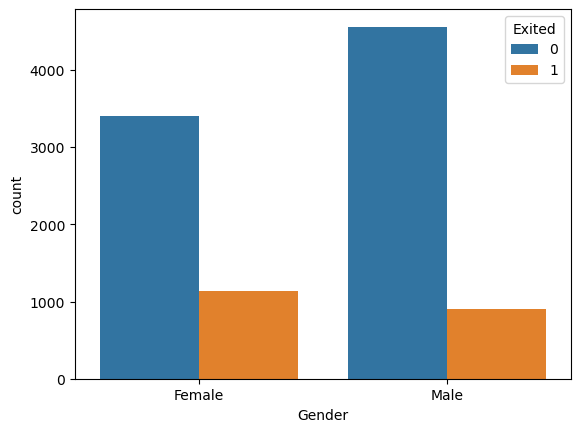

In [59]:
#Check how many customer churn in comparison to others that stay on basis of the Gender

sns.countplot(
    x='Gender',
    hue='Exited',
    data=data
)

<Axes: xlabel='Geography', ylabel='count'>

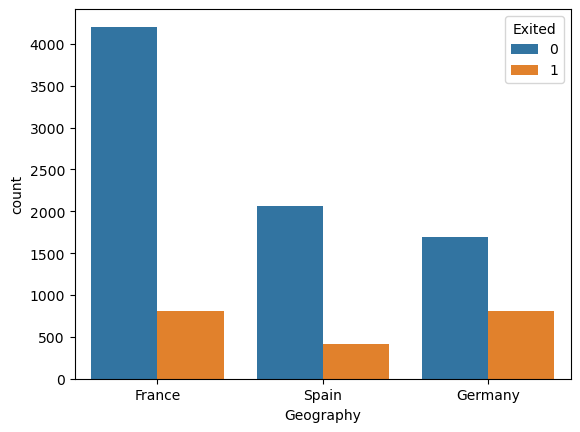

In [60]:
#Check how many customer churn in comparison to others that stay on basis of the Geography

sns.countplot(
    x='Geography',
    hue='Exited',
    data=data
)

In [44]:
#Since data has no null valus no cleaning is required here 
#Now using the label encoding here because the Machine was unable to process the columns like geography and Gender as they contain 
#String Value machine can understand only numerical values.
#Label Encoding converts the given columns values into numerical values in alphabetical order 
#EX-Female=0 and Male=1 if more values then so on alphabetically.
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()
data['Geography'] = label_enc.fit_transform(data['Geography'])
data['Gender'] = label_enc.fit_transform(data['Gender'])
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [45]:
#Now training the model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and target
x = data.drop('Exited', axis=1) #This will take all the columns except the Exited Column
y = data['Exited'] #It will take the exited column only

# Split and scale
from sklearn.model_selection import train_test_split #For splitting the given data into training and testing data
from sklearn.preprocessing import StandardScaler #For Scaling the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


#Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

#Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Decision Tree Accuracy: 0.782
[[1358  249]
 [ 187  206]]
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1607
           1       0.45      0.52      0.49       393

    accuracy                           0.78      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.80      0.78      0.79      2000

Random Forest Accuracy: 0.8645
[[1546   61]
 [ 210  183]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [46]:
#Since the accuracy of the Random Forest is the highest so we will continue with it only.
#If we want to optimize our model using hyper parameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# Hyperparameter grid
param_grid = {
'n_estimators': [50, 100, 200],
'max_depth': [10, 20, 30],
'min_samples_split': [2, 5, 10]
}
# Model
rf = RandomForestClassifier()
# Grid Search
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='accuracy')
grid_search.fit(x_train, y_train)
# Best parameters
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


In [48]:
#It gave the best paremeter to use so that our model become more optimised in nature

rf_model = RandomForestClassifier(max_depth=10, min_samples_split= 10,n_estimators=200, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8645
[[1561   46]
 [ 225  168]]
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.79      0.43      0.55       393

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.86      0.86      0.85      2000



<Axes: >

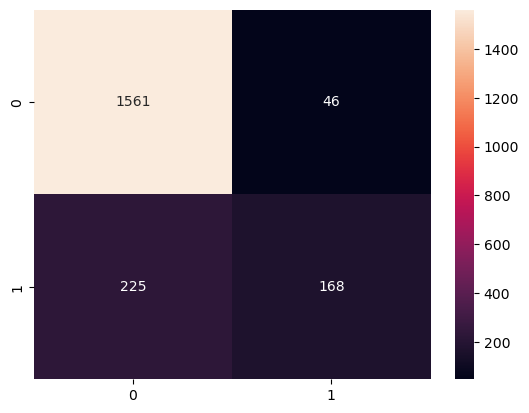

In [66]:
#Confusion Matrix for Random Forest Model

cm = confusion_matrix(y_test,y_pred_rf)
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

In [ ]:
#Save best Model that we have trained above that is Random_Forest i.e. rf_model
import pickle
with open('churn_model.pkl','wb') as f:
    pickle.dump(rf_model,f)